In [1]:
import shap, xgboost
print("shap:", shap.__version__)
print("xgboost:", xgboost.__version__)

c:\Users\Visveswaran\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


shap: 0.49.1
xgboost: 3.2.0


In [2]:
import sqlite3
import pandas as pd
import joblib
import shap
import matplotlib.pyplot as plt

conn = sqlite3.connect("../retailiq.db")
df = pd.read_sql("SELECT * FROM customer_features", conn)
conn.close()

feature_cols = [
    "frequency", "repeat_order_count", "avg_days_between_orders",
    "avg_review_score", "review_count", "avg_delivery_days", "avg_delay_days",
    "treatment_voucher"
]
target = "churned"

model_df = df[feature_cols + [target]].dropna()
X = model_df[feature_cols]

clf = joblib.load("../models_churn.pkl")

X_sample = X.sample(min(2000, len(X)), random_state=42)
explainer = shap.TreeExplainer(clf)
shap_values = explainer.shap_values(X_sample)

print("SHAP values shape:", shap_values.shape)

c:\Users\Visveswaran\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


SHAP values shape: (2000, 8)


In [3]:
import xgboost
print(xgboost.__version__)

3.2.0


In [4]:
import sys
print(sys.executable)

c:\Users\Visveswaran\AppData\Local\Programs\Python\Python310\python.exe


In [5]:
import sys
!{sys.executable} -m pip install "xgboost==1.7.6"

  Using cached xgboost-1.7.6-py3-none-win_amd64.whl (70.9 MB)
  Attempting uninstall: xgboost
    Found existing installation: xgboost 3.2.0
    Uninstalling xgboost-3.2.0:
      Successfully uninstalled xgboost-3.2.0


ERROR: Could not install packages due to an OSError: [WinError 5] Access is denied: 'C:\\Users\\Visveswaran\\AppData\\Local\\Programs\\Python\\Python310\\Lib\\site-packages\\~gboost\\lib\\xgboost.dll'
Consider using the `--user` option or check the permissions.


[notice] A new release of pip is available: 23.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import xgboost
print(xgboost.__version__)

1.7.6


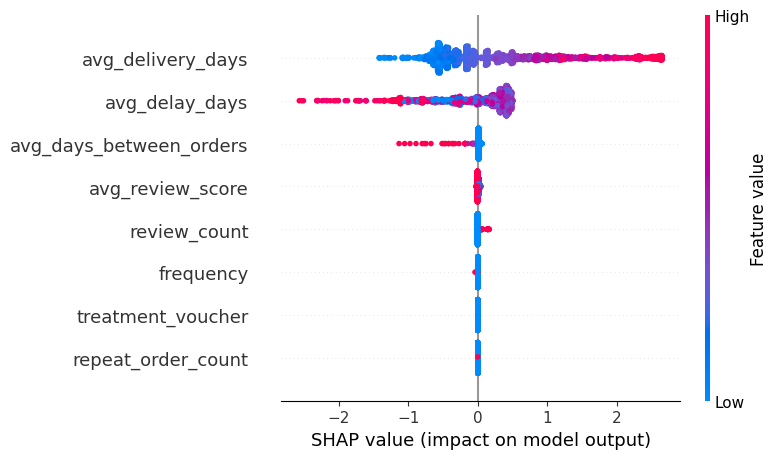

In [3]:
shap.summary_plot(shap_values, X_sample, show=False)
plt.tight_layout()
plt.savefig("../docs/shap_churn_summary.png", dpi=150, bbox_inches="tight")
plt.show()

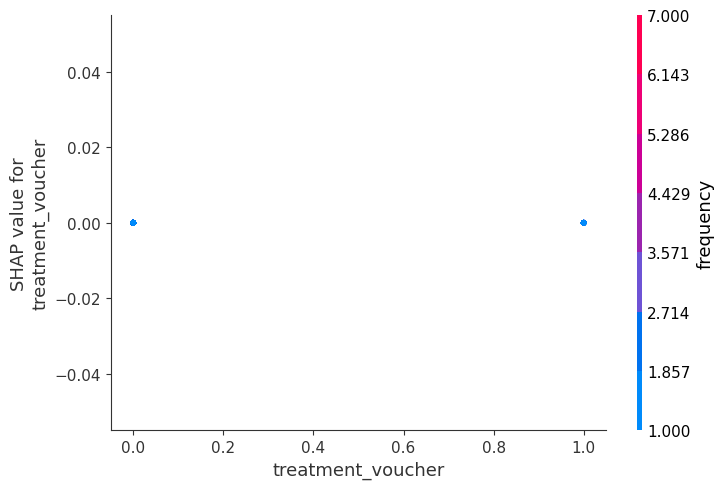

In [4]:
shap.dependence_plot("treatment_voucher", shap_values, X_sample, show=False)
plt.tight_layout()
plt.savefig("../docs/shap_churn_voucher_dependence.png", dpi=150, bbox_inches="tight")
plt.show()